# DeiTIII training
This notebook trains a DeiTIII model for multi-class classification on the ERCP dataset.

In [ ]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
try: import livelossplot
except ImportError: pip('livelossplot')
try: import timm
except ImportError: pip('timm')
try: import torchmetrics
except ImportError: pip('torchmetrics')

In [12]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                                Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                                RandRotate, RandFlip, RandShiftIntensity,
                                RandScaleIntensity, ToTensor, Compose,
                                NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import os
from PIL import Image
import random
import seaborn as sns

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score)
from sklearn.utils.class_weight import compute_class_weight

import timm
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, WeightedRandomSampler
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [13]:
# ── Configuração global ─────────────────────────
IMG_SIZE    = 224          
BATCH_SIZE  = 8          
NUM_WORKERS = 2            
MODEL_ARCH  = 'deit3_small_patch16_224'   
MODEL_PATH  = './models/deitiii_v3.pth'
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = 60
EARLY_STOP    = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM disponível: 50.9 GB


In [14]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)

## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [15]:
base_dir = 'dataset'
phases   = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train'))
                      if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)
print('Classes:', class_names)

def load_images_labels(phase):
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        files = [os.path.join(class_dir, x)
                 for x in os.listdir(class_dir) if x.lower().endswith(valid_exts)]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([i] * len(files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    counts = np.bincount(data[phase]['labels'])
    print(f"{phase.capitalize():5s}: {len(data[phase]['images'])} imgs | "
          + ' | '.join(f'{class_names[i]}={c}' for i, c in enumerate(counts)))

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train: 1067 imgs | Biliary_Leaks=110 | Lithiasis=505 | Normal=197 | Stricture=255
Val  : 234 imgs | Biliary_Leaks=24 | Lithiasis=98 | Normal=59 | Stricture=53
Test : 267 imgs | Biliary_Leaks=17 | Lithiasis=123 | Normal=43 | Stricture=84


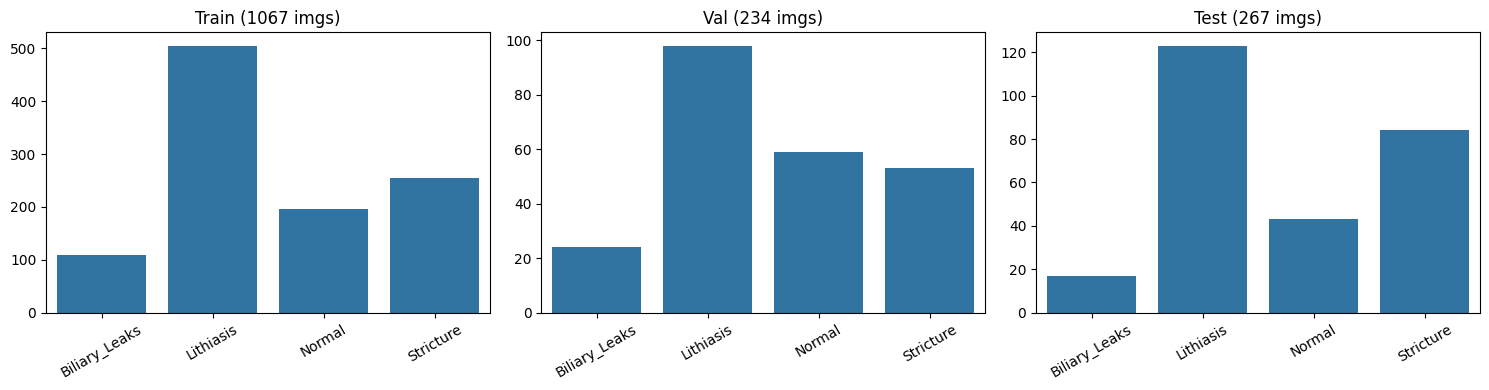

In [16]:
# Visualizar distribuição de classes
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, phase in zip(axes, phases):
    counts = np.bincount(data[phase]['labels'])
    sns.barplot(x=class_names, y=counts, ax=ax)
    ax.set_title(f'{phase.capitalize()} ({sum(counts)} imgs)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Transforms
Define data augmentation and preprocessing for training and validation, including CLAHE enhancement. Images are resized to `IMG_SIZExIMG_SIZE`.

In [17]:
def apply_clahe(img):
    """CLAHE num tensor float [C,H,W].
    LoadImage do MONAI pode devolver [0,1] ou [0,255] — detectar automaticamente.
    """
    if img.max() > 1.0:
        img_np = img.clamp(0, 255).numpy().astype('uint8')
    else:
        img_np = (img.clamp(0, 1).numpy() * 255).astype('uint8')

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    if img_np.shape[0] == 3 and np.allclose(img_np[0], img_np[1]) and np.allclose(img_np[1], img_np[2]):
        img_np[0] = clahe.apply(img_np[0])
        img_np[1] = img_np[0]
        img_np[2] = img_np[0]
    else:
        for c in range(img_np.shape[0]):
            img_np[c] = clahe.apply(img_np[c])

    return torch.tensor(img_np / 255.0, dtype=torch.float32)


def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img


train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    Lambda(apply_clahe),
    RandRotate(range_x=15, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.4),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.4),
    RandAdjustContrast(prob=0.4),
    RandShiftIntensity(offsets=0.1, prob=0.3),
    RandScaleIntensity(factors=0.15, prob=0.3),
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    Lambda(apply_clahe),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a `Dataset` (with optional Mixup) and create DataLoaders for training, validation and testing.

In [18]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):  return len(self.image_files)

    def __getitem__(self, idx):
        return self.transforms(self.image_files[idx]), self.labels[idx]

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

# WeightedRandomSampler — oversampling de classes minoritárias
class_counts          = np.bincount(data['train']['labels'])
class_weights_sampler = 1.0 / class_counts
sample_weights        = [class_weights_sampler[l] for l in data['train']['labels']]
sampler = WeightedRandomSampler(weights=sample_weights,
                                 num_samples=len(sample_weights),
                                 replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 134 | Val: 30 | Test: 34


In [19]:
def mixup_batch(inputs, labels, alpha=0.1, num_classes=4):
    """Mixup: mistura dois exemplos do batch com proporção lambda ~ Beta(alpha,alpha)."""
    if alpha <= 0:
        return inputs, nn.functional.one_hot(labels, num_classes).float()
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(inputs.size(0), device=inputs.device)
    mixed = lam * inputs + (1 - lam) * inputs[idx]
    y_a   = nn.functional.one_hot(labels, num_classes).float()
    y_b   = nn.functional.one_hot(labels[idx], num_classes).float()
    mixed_labels = lam * y_a + (1 - lam) * y_b
    return mixed, mixed_labels

## Model
Instantiate a DeiTIII backbone (pretrained) and adapt the classifier head to the number of classes.

In [20]:
import gc
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

model = timm.create_model(MODEL_ARCH, pretrained=True, in_chans=3)
model.head = nn.Linear(model.head.in_features, num_class)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais:    {total:,}')
print(f'Parâmetros treináveis: {trainable:,}')

Parâmetros totais:    21,676,036
Parâmetros treináveis: 21,676,036


In [21]:
class_weights_np     = compute_class_weight('balanced',
                                             classes=np.unique(data['train']['labels']),
                                             y=data['train']['labels'])
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Class weights:', dict(zip(class_names, class_weights_np.round(3))))

loss_function = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
auc_metric    = ROCAUCMetric()

Class weights: {'Biliary_Leaks': np.float64(2.425), 'Lithiasis': np.float64(0.528), 'Normal': np.float64(1.354), 'Stricture': np.float64(1.046)}


## Training
Define the learning-rate scheduler and `train_model` function, then run two training phases: head-only (Phase 1) and full fine-tuning (Phase 2).

In [4]:
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR

def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

In [23]:
def train_model(train_dl, val_dl, model, loss_fn, optimizer, epochs, name,
                warmup_epochs=3, use_mixup=True):
    patience              = EARLY_STOP
    epochs_no_improve     = 0
    best_metric           = -1
    best_metric_epoch     = -1
    best_train_f1         = 0.0
    metric_values         = []

    liveloss   = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{name}.png')])
    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    scheduler  = get_warmup_cosine_scheduler(optimizer, warmup_epochs, epochs)

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss     = 0.0
        running_corrects = 0.0
        y_pred_train     = torch.tensor([], dtype=torch.float32, device=device)
        y_train          = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)

            if use_mixup and epoch >= warmup_epochs:
                inputs_m, labels_soft = mixup_batch(inputs, labels,
                                                     alpha=0.4,
                                                     num_classes=num_class)
                outputs = model(inputs_m)
                log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
                loss      = -(labels_soft * log_probs).sum(dim=1).mean()
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs.detach()], dim=0)
            y_train           = torch.cat([y_train, labels], dim=0)

        epoch_loss_train = running_loss / len(train_dl.dataset)
        epoch_acc_train  = running_corrects.float() / len(train_dl.dataset)
        f1_train_value   = f1_metric(y_pred_train.argmax(dim=1), y_train)

        logs['loss']     = epoch_loss_train.item()
        logs['accuracy'] = epoch_acc_train.item()
        logs['F1']       = f1_train_value.item()

        # ── Validação ───────────
        model.eval()
        running_loss     = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_imgs, val_lbls in val_dl:
                val_imgs  = val_imgs.to(device)
                val_lbls  = val_lbls.to(device)
                outputs   = model(val_imgs)
                loss      = loss_fn(outputs, val_lbls)
                running_loss     += loss.detach() * val_imgs.size(0)
                _, preds          = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_lbls.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y,      val_lbls], dim=0)

        epoch_loss_val = running_loss / len(val_dl.dataset)
        epoch_acc_val  = running_corrects.float() / len(val_dl.dataset)
        f1_val_value   = f1_metric(y_pred.argmax(dim=1), y)

        logs['val_loss']     = epoch_loss_val.item()
        logs['val_accuracy'] = epoch_acc_val.item()
        logs['val_F1']       = f1_val_value.item()

        y_onehot   = [to_onehot(i) for i in decollate_batch(y, detach=False)]
        y_pred_act = [act(i)       for i in decollate_batch(y_pred)]
        auc_metric(y_pred_act, y_onehot)
        result = auc_metric.aggregate()
        auc_metric.reset()
        del y_pred_act, y_onehot
        metric_values.append(result)
        logs['val_AUC'] = result

        if f1_val_value > best_metric:
            best_metric       = f1_val_value
            best_metric_epoch = epoch + 1
            best_train_f1     = f1_train_value.item()
            torch.save(model.state_dict(), name)
            print('  ✓ saved best model')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f'  Epoch {epoch+1:3d} | '
              f'loss={epoch_loss_train.item():.4f} | '
              f'val_loss={epoch_loss_val.item():.4f} | '
              f'F1_train={f1_train_value:.4f} | '
              f'F1_val={f1_val_value:.4f} | '
              f'AUC={result:.4f} | '
              f'LR={optimizer.param_groups[0]["lr"]:.2e}')

        if epochs_no_improve >= patience:
            print(f'Early stopping @ epoch {epoch+1} '
                  f'| best val F1={best_metric:.4f} @ epoch {best_metric_epoch}')
            break

        liveloss.update(logs)
        liveloss.send()
        scheduler.step()

    print(f'\nTreino concluído | best val F1: {best_metric:.4f} @ epoch {best_metric_epoch}')
    return best_metric.item()

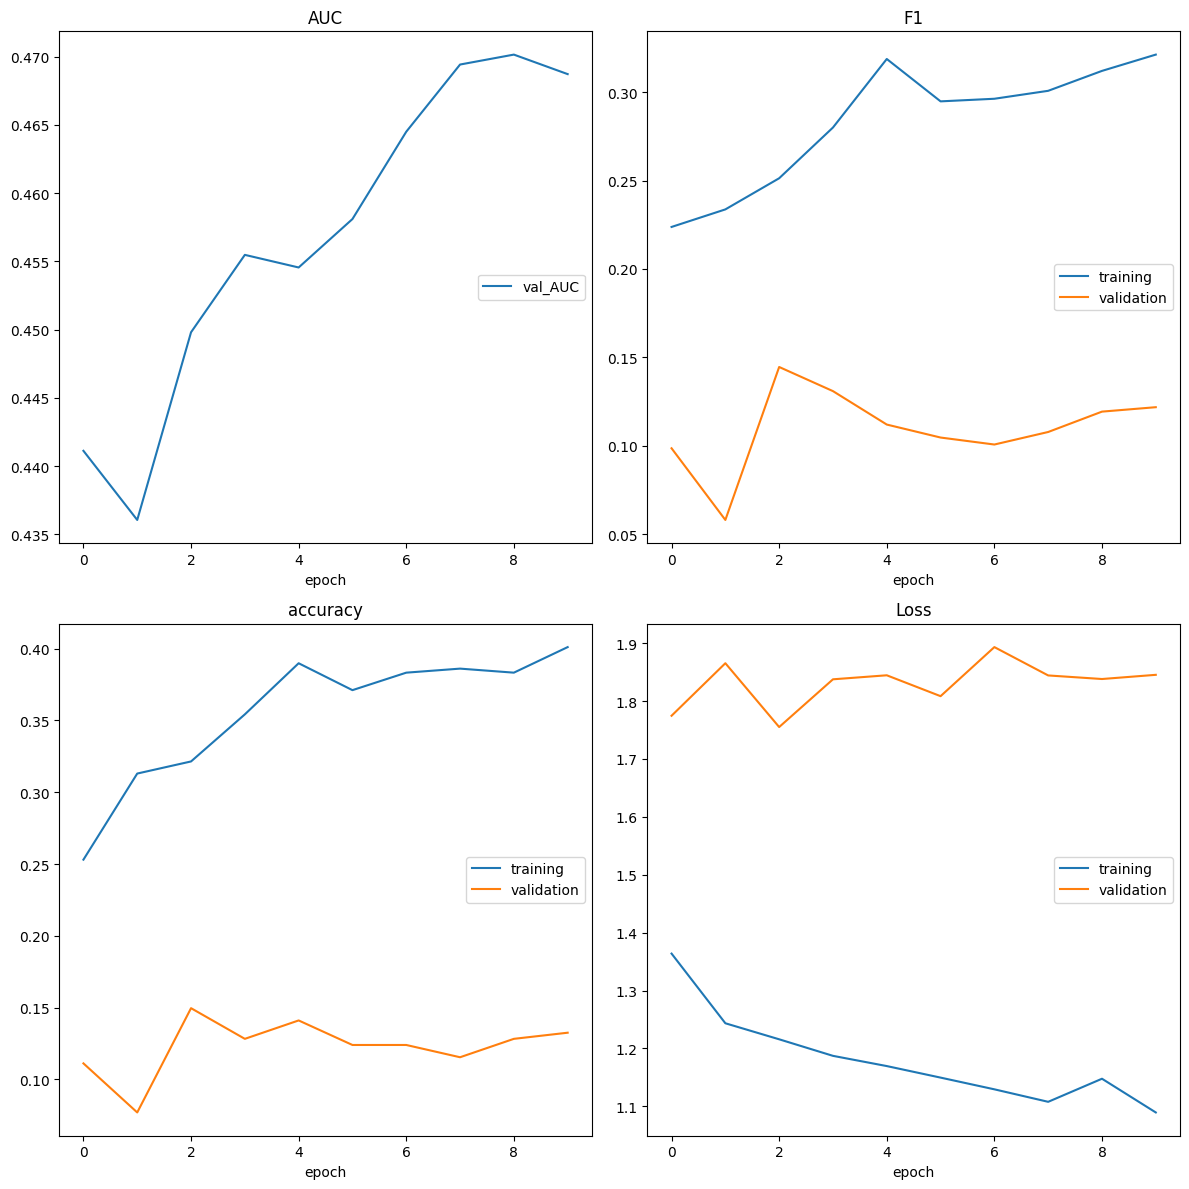


Treino concluído | best val F1: 0.1446 @ epoch 3
Phase 1 concluída em 1.5 min


In [24]:
for name_p, param in model.named_parameters():
    param.requires_grad = 'head' in name_p

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — parâmetros treináveis (head): {trainable:,}')

optimizer_warmup = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4, weight_decay=1e-4
)

t0 = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_warmup, PHASE1_EPOCHS, MODEL_PATH,
            warmup_epochs=2, use_mixup=False)   # sem mixup no warm-up
print(f'Phase 1 concluída em {(time.perf_counter()-t0)/60:.1f} min')

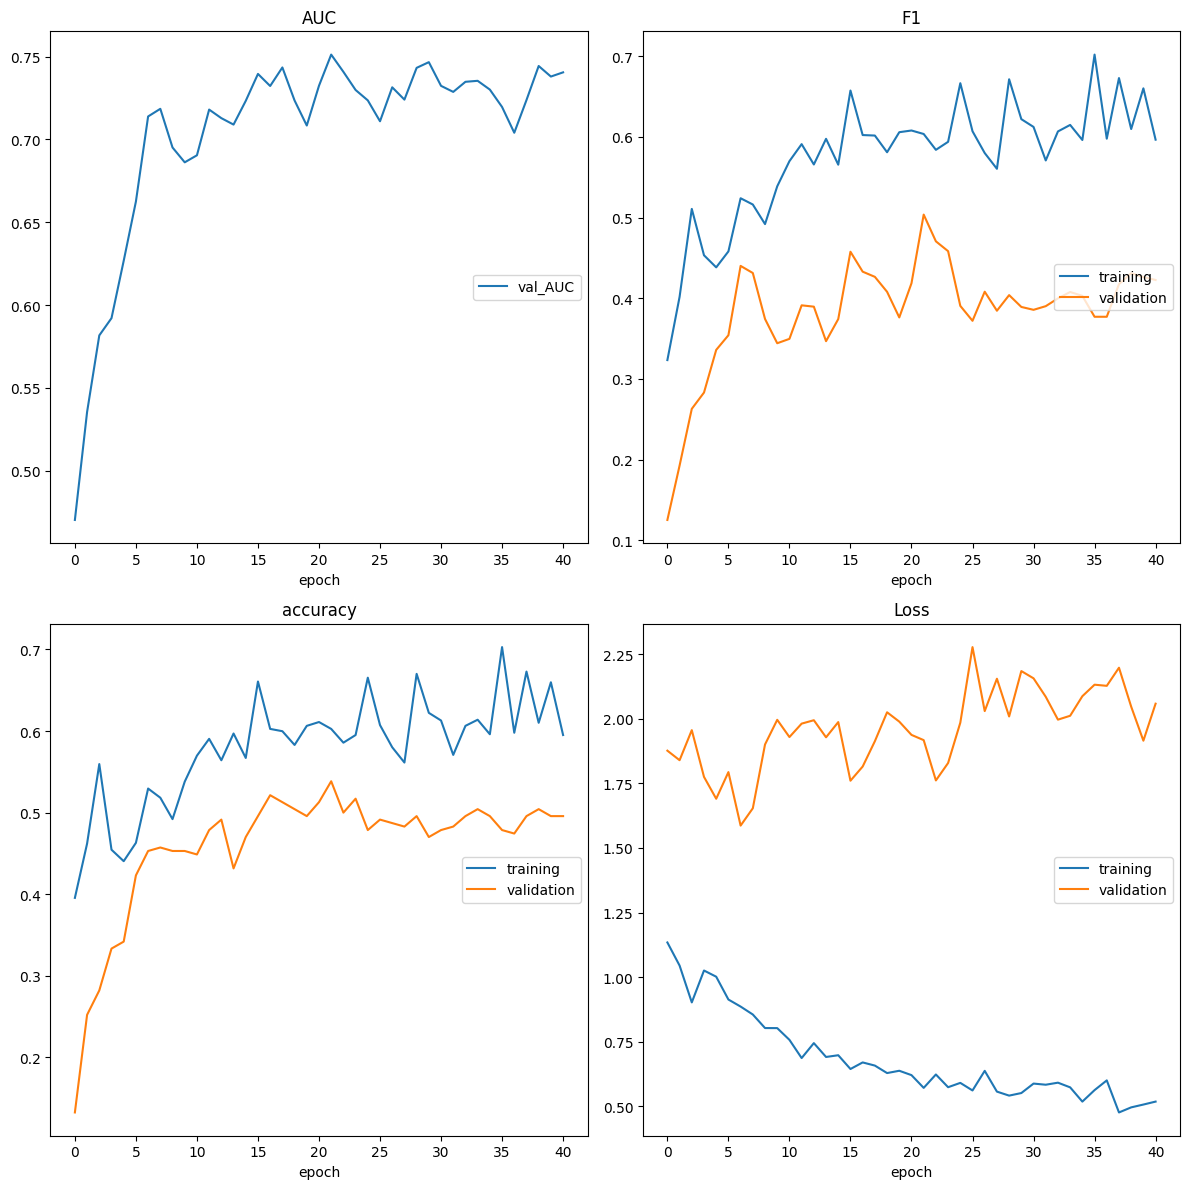

  Epoch  42 | loss=0.5146 | val_loss=1.9621 | F1_train=0.6494 | F1_val=0.4309 | AUC=0.7428 | LR=2.50e-06
Early stopping @ epoch 42 | best val F1=0.5037 @ epoch 22

Treino concluído | best val F1: 0.5037 @ epoch 22
Phase 2 concluída em 7.2 min


In [25]:
# Carregar o melhor checkpoint da Phase 1
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — parâmetros treináveis (todos): {trainable:,}')

optimizer_finetune = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'head' not in n],
     'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.head.parameters(),
     'lr': 1e-4, 'weight_decay': 1e-4},
])

t0 = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_finetune, PHASE2_EPOCHS, MODEL_PATH,
            warmup_epochs=3, use_mixup=True)
print(f'Phase 2 concluída em {(time.perf_counter()-t0)/60:.1f} min')

## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix and AUC-ROC curves.

In [26]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        out    = model(inputs)
        probs  = torch.softmax(out, dim=1).cpu().numpy()
        preds  = np.argmax(probs, axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.append(probs)

all_probs = np.vstack(all_probs)
f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n=== RESULTADOS NO TESTE ===')
print(f'F1-Score (macro): {f1:.4f}')
print(f'Accuracy:         {acc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=class_names,
                              digits=4, zero_division=0))


=== RESULTADOS NO TESTE ===
F1-Score (macro): 0.5954
Accuracy:         0.6442

               precision    recall  f1-score   support

Biliary_Leaks     0.5333    0.4706    0.5000        17
    Lithiasis     0.6400    0.7805    0.7033       123
       Normal     0.5854    0.5581    0.5714        43
    Stricture     0.7213    0.5238    0.6069        84

     accuracy                         0.6442       267
    macro avg     0.6200    0.5833    0.5954       267
 weighted avg     0.6500    0.6442    0.6388       267



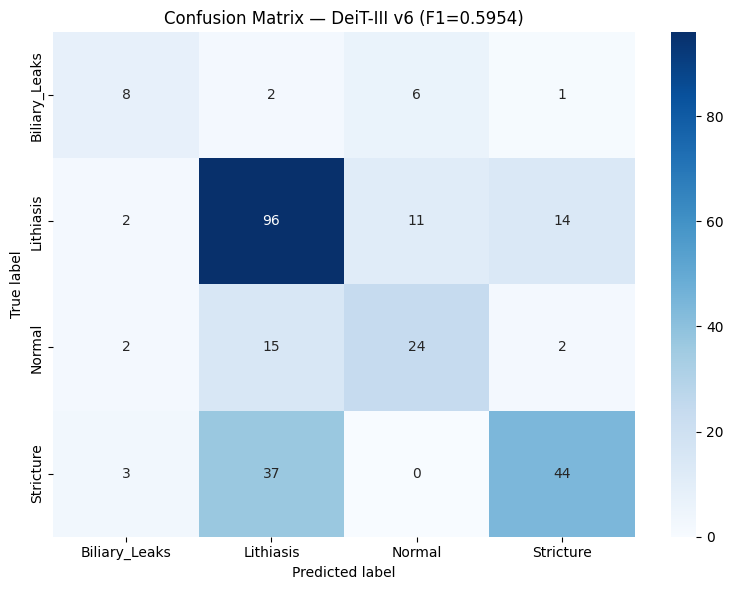

In [27]:
# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title(f'Confusion Matrix — DeiT-III v3 (F1={f1:.4f})')
plt.tight_layout()
plt.savefig('deitiii_v3_cm.png', dpi=300)
plt.show()

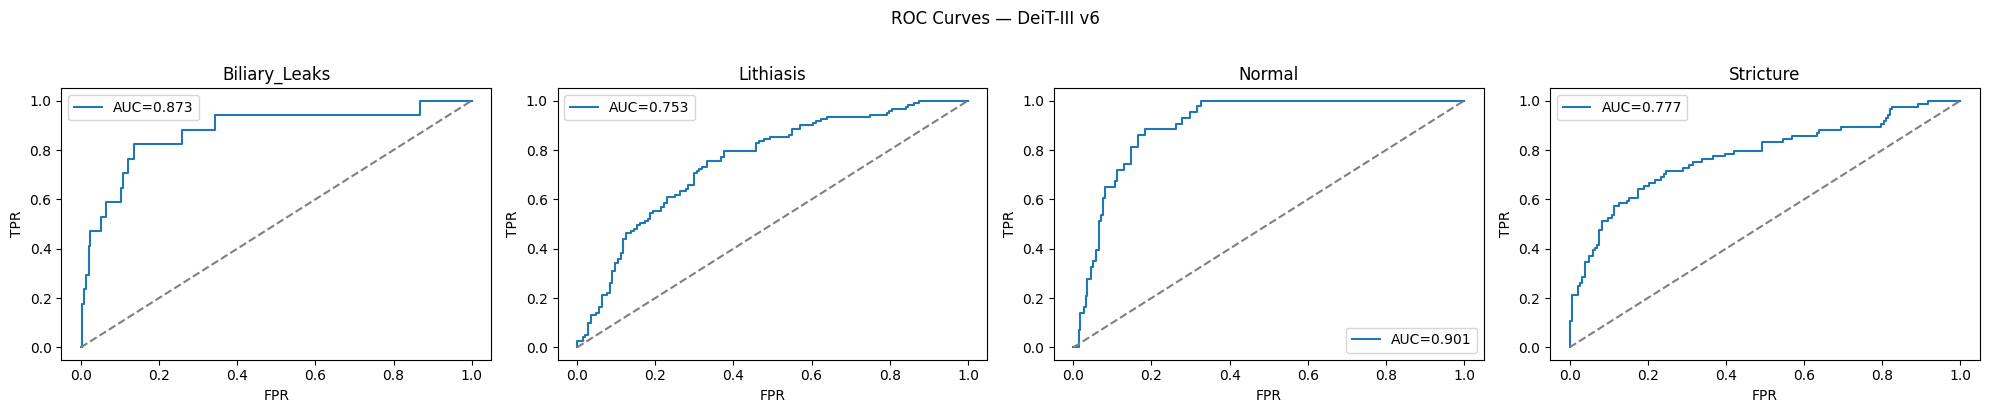

Macro AUC-ROC: 0.8263


In [28]:
# AUC-ROC por classe
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

y_bin = label_binarize(all_labels, classes=list(range(num_class)))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cls) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_title(cls); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend()
plt.suptitle('ROC Curves — DeiT-III v3', y=1.02)
plt.tight_layout()
plt.savefig('deitiii_v3_roc.png', dpi=300)
plt.show()

macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'Macro AUC-ROC: {macro_auc:.4f}')

## GradCAM
Visualize gradient-based saliency maps to interpret model predictions on test images.

In [29]:
class ViTGradCAM:
    """Gradient-based saliency map para timm DeiT-III."""
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        last_block = model.blocks[-1]
        last_block.register_forward_hook(self._save_act)
        last_block.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):
        self.activations = o.detach()  # [B, N, C]

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()  # [B, N, C]

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        inp = input_tensor.unsqueeze(0).to(device)
        inp.requires_grad_(True)
        out = self.model(inp)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        grads   = self.gradients[0]      # [N, C]
        acts    = self.activations[0]    # [N, C]
        weights = grads.mean(dim=0)      # [C]
        cam     = (acts * weights).sum(dim=-1)  # [N]
        cam     = cam[1:]                # remover CLS token
        h = w   = int(cam.shape[0] ** 0.5)
        cam = cam.reshape(h, w).cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam, class_idx

Grad-CAM guardado em gradcam_deitiii_v6.png


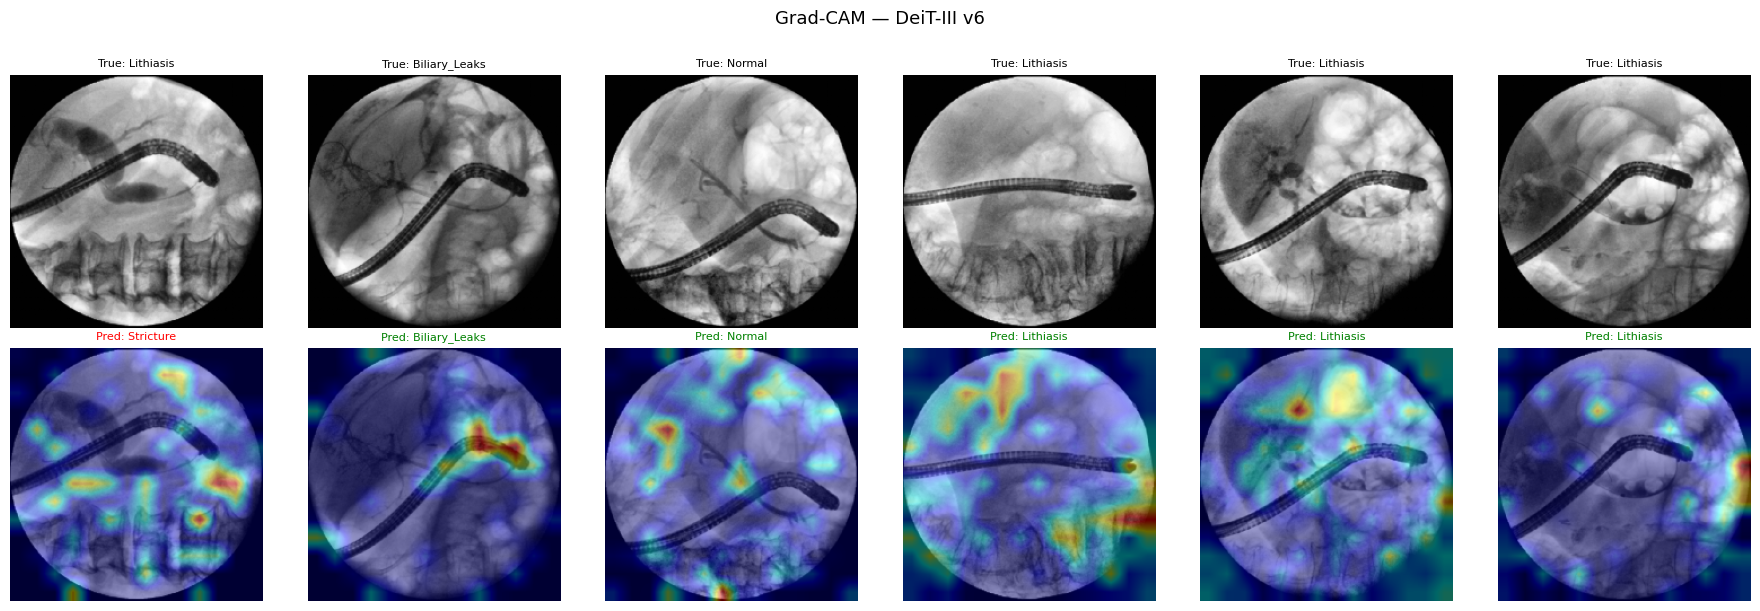

In [30]:
def show_gradcam(model, data, class_names, val_transforms, num_samples=6, save_path=None):
    grad_cam = ViTGradCAM(model)
    indices  = random.sample(range(len(data['test']['images'])), num_samples)
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    fig.suptitle('Grad-CAM — DeiT-III v3', fontsize=13, y=1.01)

    for col, idx in enumerate(indices):
        img_path   = data['test']['images'][idx]
        true_label = data['test']['labels'][idx]
        img_tensor = val_transforms(img_path)

        img_np = img_tensor[0].numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        axes[0, col].imshow(img_np, cmap='gray')
        axes[0, col].set_title(f'True: {class_names[true_label]}', fontsize=8)
        axes[0, col].axis('off')

        cam, pred_idx = grad_cam.generate(img_tensor)
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        img_rgb = np.stack([img_np] * 3, axis=-1)
        overlay = np.clip(0.6 * img_rgb + 0.4 * heatmap, 0, 1)

        axes[1, col].imshow(overlay)
        color = 'green' if pred_idx == true_label else 'red'
        axes[1, col].set_title(f'Pred: {class_names[pred_idx]}', fontsize=8, color=color)
        axes[1, col].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Grad-CAM guardado em {save_path}')
    plt.show()

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
show_gradcam(model, data, class_names, val_transforms, num_samples=6,
             save_path='gradcam_deitiii_v3.png')

Guardado em gradcam_per_class_deitiii_v6.png


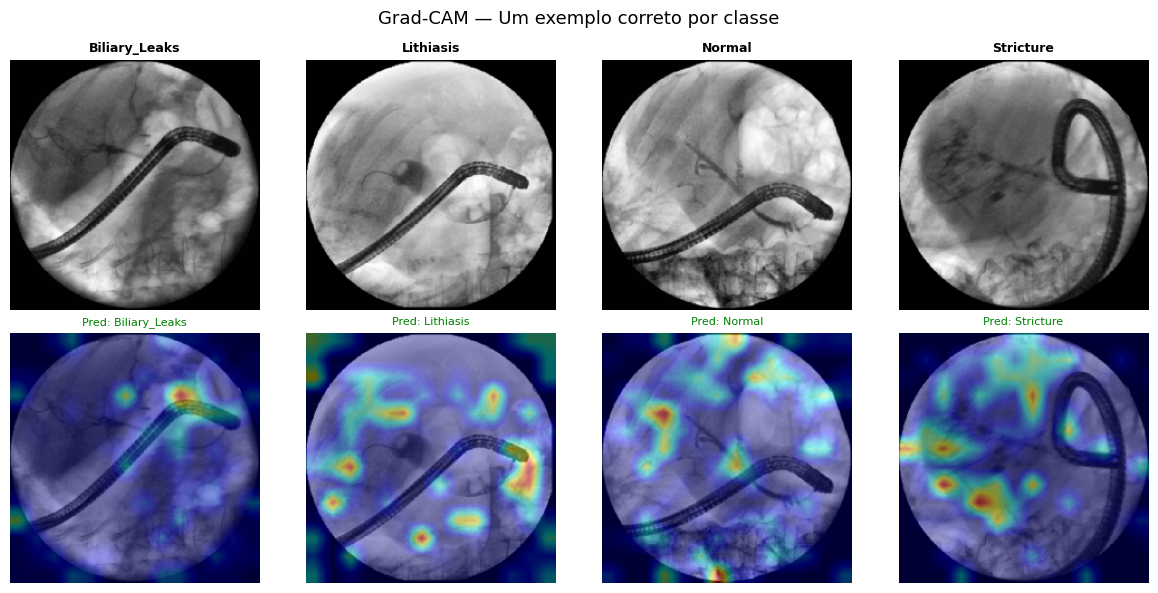

In [31]:
def show_gradcam_per_class(model, data, class_names, val_transforms, save_path=None):
    grad_cam = ViTGradCAM(model)
    found    = {}
    model.eval()

    for img_path, true_label in zip(data['test']['images'], data['test']['labels']):
        if true_label in found:
            continue
        img_tensor = val_transforms(img_path)
        with torch.no_grad():
            pred = model(img_tensor.unsqueeze(0).to(device)).argmax(dim=1).item()
        if pred == true_label:
            found[true_label] = (img_path, true_label)
        if len(found) == len(class_names):
            break

    n = len(found)
    fig, axes = plt.subplots(2, n, figsize=(n * 3, 6))
    fig.suptitle('Grad-CAM — Um exemplo correto por classe', fontsize=13)

    for col, cls_idx in enumerate(sorted(found.keys())):
        img_path, true_label = found[cls_idx]
        img_tensor = val_transforms(img_path)

        img_np = img_tensor[0].numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        axes[0, col].imshow(img_np, cmap='gray')
        axes[0, col].set_title(class_names[true_label], fontsize=9, fontweight='bold')
        axes[0, col].axis('off')

        cam, pred_idx = grad_cam.generate(img_tensor)
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        img_rgb = np.stack([img_np] * 3, axis=-1)
        overlay = np.clip(0.6 * img_rgb + 0.4 * heatmap, 0, 1)

        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f'Pred: {class_names[pred_idx]}', fontsize=8, color='green')
        axes[1, col].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Guardado em {save_path}')
    plt.show()

show_gradcam_per_class(model, data, class_names, val_transforms,
                        save_path='gradcam_per_class_deitiii_v3.png')